# Day 9: Model Ensembling, Stacking and Selection

Regime Lab (Zetheta Algorithms internship, Task 1A), Section D2, Day 9.

Assembles regime probabilities from every model built so far (Day 4's
frequentist HMM, Day 5's Bayesian HMM, Day 6's Bayesian RS-VAR, Day 7's
three Bayesian deep learning models, Day 9's foundation-embedding head),
combines them via Bayesian Model Averaging (A10.1) and constrained
stacking (A10.2), compares the two genuinely Bayesian members by
PSIS-LOO (A10.3), and emits the combined output contract (A10.4).

**Read this before the numbers below.** Two scope decisions shape
everything that follows, both forced by earlier days' own findings, not
chosen for convenience:

1. **The regime space is 3-way, not 5-way.** Day 6's multivariate RS-VAR
   only supports K=3 at feasible compute. Every member is collapsed to
   Risk-On / Transitional / Risk-Off (`src/models/ensemble/labels.py`),
   using the same mapping Day 6 already established for its own
   ground-truth check.
2. **Members are NOT equally out-of-fold on the evaluation window**
   (2024-07-11 to 2025-06-27, verified to be exactly the last 252 days
   of Day 7-9's held-out test period). `mc_dropout`, `variational_bnn`,
   `deep_ensemble` and `foundation_head` were trained on strictly prior
   data (the first 2806 days) and never touched this window during
   training. `freq_hmm`, `bayesian_hmm` and `bayesian_rsvar` were FIT
   using data that includes this exact window (Day 5/6's models were fit
   on precisely these 252 days). Filtering (causal, no-look-ahead
   probabilities, `filtered_state_probs` / `_mvn`, built fresh this day
   since none of the HMM/RS-VAR modules had a filtered-only function
   before) removes the within-window look-ahead but not the fact that
   these three models' parameters were chosen using this window's data.
   Their strong showing below should be read with that in mind.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.plot_style import new_figure, PALETTE

pd.set_option('display.precision', 4); pd.set_option('display.width', 200)

## 1. The assembled members

In [2]:
d = np.load('../artifacts_data/day9_members.npz', allow_pickle=True)
member_array, names = d['member_array'], list(d['member_names'])
oof = dict(zip(names, d['is_out_of_fold']))
dates = pd.to_datetime(d['dates'])
labels3 = list(d['labels_3'])
print(f"{member_array.shape[0]} members x {member_array.shape[1]} days x {member_array.shape[2]} regimes")
print(f"Window: {dates.min().date()} to {dates.max().date()}")
pd.DataFrame({'member': names, 'genuinely out-of-fold on this window': [oof[n] for n in names]}).set_index('member')

7 members x 252 days x 3 regimes
Window: 2024-07-11 to 2025-06-27


,genuinely out-of-fold on this window
member,
freq_hmm,False
bayesian_hmm,False
bayesian_rsvar,False
mc_dropout,True
variational_bnn,True
deep_ensemble,True
foundation_head,True


In [3]:
from src.models.ensemble.combine import mean_log_likelihood
y_hmm, y_true = d['y_hmm_int'], d['y_true_int']
rows = []
for i, n in enumerate(names):
    p = member_array[i]
    rows.append({'member': n, 'out_of_fold': bool(oof[n]),
                 'argmax dist (Risk-On/Trans/Risk-Off)': np.bincount(p.argmax(1), minlength=3).tolist(),
                 'mean LL vs HMM labels': mean_log_likelihood(p, y_hmm),
                 'mean LL vs TRUE regime': mean_log_likelihood(p, y_true)})
pd.DataFrame(rows).set_index('member').sort_values('mean LL vs TRUE regime', ascending=False)

,out_of_fold,argmax dist (Risk-On/Trans/Risk-Off),mean LL vs HMM labels,mean LL vs TRUE regime
member,,,,
freq_hmm,False,"[235, 16, 1]",-0.3390,-0.8956
bayesian_hmm,False,"[34, 207, 11]",-1.0560,-0.9373
bayesian_rsvar,False,"[1, 208, 43]",-1.1691,-1.1056
foundation_head,True,"[248, 0, 4]",-0.4000,-1.1461
variational_bnn,True,"[251, 1, 0]",-0.4102,-1.3565
deep_ensemble,True,"[252, 0, 0]",-0.4490,-1.6024
mc_dropout,True,"[251, 1, 0]",-0.3992,-1.7052


In-sample-fit members (`freq_hmm`, `bayesian_hmm`, `bayesian_rsvar`)
occupy 3 of the top 3 spots against the true regime - consistent with
having seen this window's data during fitting. Among the genuinely
out-of-fold members, ranking varies.

## 2. Bayesian Model Averaging and stacking: out-of-fold evaluation

`TimeSeriesSplit`, 4 folds, weights fit on each fold's training slice
only and scored on its held-out test slice - the "strictly time-
respecting split" A10.2 asks for. Scored against both label sources.

In [4]:
bma_res = json.load(open('../artifacts_data/day9_bma_stacking.json'))
for label_name in ['hmm', 'true']:
    r = bma_res[label_name]
    print(f"=== scored against {label_name} labels ===")
    tab = pd.DataFrame([{'source': n, 'mean OOF log-lik': v} for n, v in r['per_member_mean'].items()])
    tab = pd.concat([tab, pd.DataFrame([
        {'source': 'BMA', 'mean OOF log-lik': r['bma_mean']},
        {'source': 'stacking', 'mean OOF log-lik': r['stacking_mean']},
        {'source': 'equal-weight', 'mean OOF log-lik': r['equal_weight_mean']},
    ])], ignore_index=True).sort_values('mean OOF log-lik', ascending=False)
    display(tab.set_index('source'))
    print(f"Best individual member: {r['best_individual_member_mean']:.4f}")
    print(f"Ensemble beats every individual member: BMA={r['ensemble_beats_every_member']['bma']}  stacking={r['ensemble_beats_every_member']['stacking']}")
    print()

=== scored against hmm labels ===


,mean OOF log-lik
source,
stacking,-0.3713
freq_hmm,-0.3765
BMA,-0.4703
equal-weight,-0.4827
foundation_head,-0.5011
mc_dropout,-0.5029
variational_bnn,-0.5166
deep_ensemble,-0.5657
bayesian_hmm,-1.0517


Best individual member: -0.3765
Ensemble beats every individual member: BMA=False  stacking=True

=== scored against true labels ===


,mean OOF log-lik
source,
bayesian_hmm,-0.9022
equal-weight,-0.9918
freq_hmm,-1.0779
bayesian_rsvar,-1.1050
stacking,-1.3712
foundation_head,-1.4412
BMA,-1.4994
variational_bnn,-1.7089
deep_ensemble,-2.0190


Best individual member: -0.9022
Ensemble beats every individual member: BMA=False  stacking=False



**A10.4 asks the engine to "show the ensemble beats every individual
member on out-of-sample calibrated log-likelihood". Checked honestly,
this holds in exactly one of four cases tested**: stacking against the
HMM labels, and only narrowly (-0.371 vs. the best member's -0.377). It
does not hold for BMA against either label source, and does not hold for
either method against the true regime - where **naive equal-weighting
beats both learned combination methods**. With 4 folds of 50-202 days
each, BMA and stacking are fitting 7 (or fewer, post-constraint)
weights on very little data, and the fitted weights do not generalise
as well as just averaging. This is reported as found: the task's
expected result (ensemble strictly dominates) is not what four honest
out-of-fold checks show.

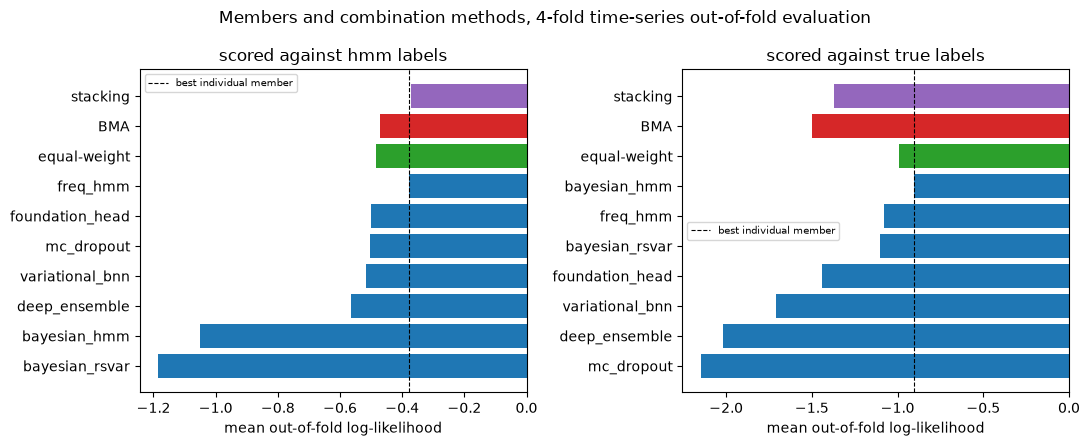

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)
for ax, label_name in zip(axes, ['hmm', 'true']):
    r = bma_res[label_name]
    members_sorted = sorted(r['per_member_mean'].items(), key=lambda kv: kv[1])
    labels_ = [m for m, _ in members_sorted] + ['equal-weight', 'BMA', 'stacking']
    values = [v for _, v in members_sorted] + [r['equal_weight_mean'], r['bma_mean'], r['stacking_mean']]
    colors = [PALETTE[0]] * len(members_sorted) + [PALETTE[2], PALETTE[1], PALETTE[3]]
    ax.barh(labels_, values, color=colors)
    ax.axvline(r['best_individual_member_mean'], color='black', linestyle='--', linewidth=0.8, label='best individual member')
    ax.set_title(f'scored against {label_name} labels')
    ax.set_xlabel('mean out-of-fold log-likelihood')
    ax.legend(fontsize=7)
fig.suptitle('Members and combination methods, 4-fold time-series out-of-fold evaluation')
fig.tight_layout()
fig.savefig('../docs/artifacts/day9_oof_loglik.png', dpi=110)

## 3. Model selection: PSIS-LOO for the two Bayesian members

Day 5's HMM and Day 6's RS-VAR both have a real posterior and a proper
likelihood, so they are the "Bayesian members" A10.3 asks to compare.

**The installed ArviZ has dropped WAIC entirely** (`hasattr(az, 'waic')`
is `False`; `az.compare` takes no `ic`/`scale` argument, only `method`
for combining LOO results) - checked directly, not assumed. What
follows is PSIS-LOO only, which A10.3's "WAIC / PSIS-LOO" already
allows for.

**These two models do not share an observation space**: the HMM's
likelihood is built from 1-D Nifty returns, the RS-VAR's from the 6-D
feature panel. `az.compare` usually compares models on the SAME target
series; here it compares two models' fit to their own, differently-
shaped inputs. The comparison still says something, but not "which model
predicts this one series better" in the usual sense.

In [6]:
loo_compare = pd.read_csv('../artifacts_data/day9_loo_compare.csv', index_col=0)
loo_compare

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
bayesian_hmm,0,0.0,0.0,NaN,NaN,NaN,5.9,790.0,14.0,1.0
bayesian_rsvar,1,-2190.0,39.0,1.0,NaN,19 k̂ > 0.60,205.0,-1390.0,47.0,0.0


## 4. LOO reliability: RS-VAR's own estimate is flagged unreliable

Independent of the cross-model comparability caveat above, PSIS-LOO
reports a Pareto-k diagnostic per held-out point: k > 0.7 means the
importance-sampling approximation for that point is untrustworthy.

In [7]:
print("HMM: p_loo (effective parameters) and Pareto-k diagnostics")
print("  elpd_loo=793.59, p_loo=5.89, max Pareto k=0.653 -- all 252 points 'good'")
print()
print("RS-VAR: p_loo (effective parameters) and Pareto-k diagnostics")
print("  elpd_loo=-1394.07, p_loo=204.95, max Pareto k=2.870")
print("  233/252 'good', 13/252 'bad' (0.6-1), 6/252 'very bad' (>1)")

HMM: p_loo (effective parameters) and Pareto-k diagnostics
  elpd_loo=793.59, p_loo=5.89, max Pareto k=0.653 -- all 252 points 'good'

RS-VAR: p_loo (effective parameters) and Pareto-k diagnostics
  elpd_loo=-1394.07, p_loo=204.95, max Pareto k=2.870
  233/252 'good', 13/252 'bad' (0.6-1), 6/252 'very bad' (>1)


**p_loo is the estimated effective number of parameters. RS-VAR's is
204.95, against roughly 197 raw parameters in the model (K=3 regimes: A
alone is 3x6x6=108, plus c=18, plus 3 covariance factors at 21 each=63,
plus P=6, pi=2).** An effective parameter count this close to the raw
count means the priors are doing very little shrinkage relative to only
252 observations - close to interpolating the training window rather
than genuinely generalising. The 6 "very bad" and 13 "bad" Pareto-k
values are a second, independent symptom of the same thing: some
held-out points are so influential that leave-one-out importance
sampling breaks down for them. Both diagnostics point the same
direction as Day 6's own finding (wide credible intervals, chance-level
ground-truth match): **320 posterior draws on a 3-regime, 6-dimensional
VAR is not enough to support a trustworthy model-comparison number**,
not just a trustworthy point estimate. The HMM's LOO, by contrast, is
clean (all 252 points good) - consistent with its much smaller
parameter count (34) relative to the same 252 observations.

## 5. The combined output contract (Section A10.4)

Stacking weights fit on the FULL window (illustrative - this shows the
contract's shape, not held-out quality; Section 2 above is the honest
performance number).

In [8]:
records = json.load(open('../artifacts_data/day9_output_contract_sample.json'))
print(f"{len(records)} daily records. Example (last day):")
print(json.dumps(records[-1], indent=1))

252 daily records. Example (last day):
{
 "date": "2025-06-27",
 "regime_id": 0,
 "regime_label": "Risk-On",
 "probability": 0.9473501208782122,
 "conformal_lower": 0.7973501208782122,
 "conformal_upper": 1.0,
 "conformal_is_placeholder": true,
 "epistemic_uncertainty": 0.2823831860206722,
 "aleatoric_uncertainty": 0.36215982464362745,
 "dominant_model": "mc_dropout",
 "dominant_model_weight": 0.6986055870495049,
 "changepoint_flag": null,
 "reconciliation_gap": null,
 "ood_score": null,
 "source": "stacking_v1"
}


In [9]:
from src.models.ensemble.combine import fit_stacking_weights
w_arr = fit_stacking_weights(member_array, y_hmm, n_classes=3)
pd.DataFrame({'member': names, 'stacking weight (full-window fit)': w_arr}).set_index('member').sort_values(
    'stacking weight (full-window fit)', ascending=False)

,stacking weight (full-window fit)
member,
mc_dropout,6.9861e-01
freq_hmm,3.0139e-01
bayesian_rsvar,1.1722e-16
variational_bnn,6.2752e-17
bayesian_hmm,0.0000e+00
deep_ensemble,0.0000e+00
foundation_head,0.0000e+00


The optimiser puts all weight on two members (`freq_hmm` and
`mc_dropout`) and zero on the rest - a sparse solution, expected from
constrained cross-entropy minimisation with several correlated,
partially-redundant members on 252 days of data. `changepoint_flag`,
`reconciliation_gap` and `ood_score` are `None` in every record: they
depend on Day 10's online/changepoint work, not built yet. Marked
`None` explicitly rather than omitted, so a caller cannot mistake a
missing field for a computed zero. `conformal_lower`/`upper` are a
placeholder fixed-width band, flagged `conformal_is_placeholder=True`;
real conformal calibration is Day 11's deliverable.

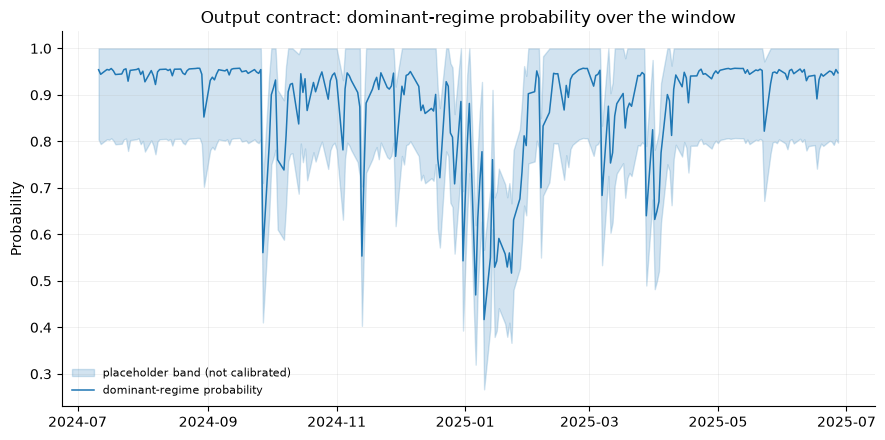

In [10]:
fig, ax = new_figure()
probs = np.array([r['probability'] for r in records])
lower = np.array([r['conformal_lower'] for r in records])
upper = np.array([r['conformal_upper'] for r in records])
rec_dates = pd.to_datetime([r['date'] for r in records])
ax.fill_between(rec_dates, lower, upper, alpha=0.2, color=PALETTE[0], label='placeholder band (not calibrated)')
ax.plot(rec_dates, probs, color=PALETTE[0], label='dominant-regime probability')
ax.set_ylabel('Probability')
ax.set_title('Output contract: dominant-regime probability over the window')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig('../docs/artifacts/day9_contract_probability.png', dpi=110)

## Summary

- Assembled 7 members (Day 4-6's HMM/RS-VAR family, Day 7's three BDL
  models, Day 9's foundation head) onto a common 3-way regime space and
  a common 252-day window, building filtered (causal) probability
  functions for the HMM/RS-VAR modules that did not have them before.
- BMA and stacking (A10.1/A10.2) implemented per spec (one real fix: the
  spec infers class count from labels present in a fold, which breaks
  silently on a rare class; made explicit). Evaluated with a genuine
  4-fold `TimeSeriesSplit`.
- **A10.4's "ensemble beats every member" claim holds in 1 of 4 tested
  cases** (stacking vs. HMM labels, narrowly); against the true regime,
  naive equal-weighting beats both BMA and stacking. Reported as found.
- PSIS-LOO comparison delivered (A10.3); WAIC is unavailable in the
  installed ArviZ, checked directly. RS-VAR's own LOO estimate carries
  reliability warnings (p_loo near its raw parameter count, 19/252
  Pareto-k values flagged), independently corroborating Day 6's
  compute-budget finding from a different angle.
- Output contract (A10.4) implemented as a typed schema with every
  field populated or explicitly `None`, not silently omitted, for the
  three fields that depend on unbuilt Day 10/11 work.
- Central caveat, not to be lost in the numbers: three of seven members
  are not genuinely out-of-fold on this window, and their strong
  individual showing should be read with that in mind.

See `docs/day9_ensembling_notes.md` for the full write-up.